Source: [NCHS / CDC](https://www.cdc.gov/nchs/fastats/life-expectancy.htm)<br>
[List of U.S. states and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_life_expectancy) <i>([alternative design](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_U.S._states_and_territories_by_life_expectancy_(alternative)))</i> / [Продолжительность жизни в штатах США](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_штатах_США)<br>
[MapChart](https://www.mapchart.net/usa.html)<br>
[chart from the National Vital Statisctics Reports at wiki](https://en.wikipedia.org/wiki/File:Percentage_Surviving_to_Certain_Ages_in_the_U.S..png)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import re
from collections import namedtuple

In [3]:
pd.options.display.min_rows=6

In [4]:
LANGS = ['en']  # languages of the charts (this setting doesn't have influence on tables)  #['en', 'ru', 'nolang']
DESTINATION_OUTPUT = 'show'  # to where table code should be placed: 'file', 'show'

In [5]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'color', 'style', 'width', 'alpha'])

In [6]:
def read_single_csv(file_name):
    return pd.read_csv(f"data 2019 number of surviving/{file_name}", sep='\t',
                usecols=['Age', 'Probability_of_dying_between_ages_x_and_x_next'], index_col='Age') * 100

ls_files = ['All population, males.csv',
            'All population, total.csv',
            'All population, females.csv',
            'Hispanic population, males.csv',
            'Hispanic population, total.csv',
            'Hispanic population, females.csv',
            'American Indian or Alaska Native population, males.csv',
            'American Indian or Alaska Native population, total.csv',
            'American Indian or Alaska Native population, females.csv',
            'Asian population, males.csv',
            'Asian population, total.csv',
            'Asian population, females.csv',
            'Black population, males.csv',
            'Black population, total.csv',
            'Black population, females.csv',
            'White population, males.csv',
            'White population, total.csv',
            'White population, females.csv']

df = pd.concat([read_single_csv(file_name) for file_name in ls_files], axis='columns')
df.index.name = ''
df.rename(index=lambda st: int(st.split('–')[0]), inplace=True)
df.columns = ['all_m', 'all_t', 'all_f',
              'hispanic_m', 'hispanic_t', 'hispanic_f',
              'native_m', 'native_t', 'native_f',
              'asian_m', 'asian_t', 'asian_f',
              'black_m', 'black_t', 'black_f',
              'white_m', 'white_t', 'white_f']

df.drop(index=100, inplace=True)

df

,all_m,all_t,all_f,hispanic_m,hispanic_t,hispanic_f,native_m,native_t,native_f,asian_m,asian_t,asian_f,black_m,black_t,black_f,white_m,white_t,white_f
,,,,,,,,,,,,,,,,,,
0,0.6080,0.5575,0.5045,0.5477,0.5034,0.4572,0.8649,0.7871,0.7062,0.3626,0.3373,0.3100,1.1407,1.0611,0.9788,0.4937,0.4479,0.3997
1,0.0415,0.0379,0.0341,0.0328,0.0305,0.0275,0.1063,0.0989,0.0907,0.0165,0.0180,0.0196,0.0699,0.0711,0.0639,0.0414,0.0341,0.0264
2,0.0257,0.0234,0.0209,0.0192,0.0183,0.0170,0.0626,0.0657,0.0681,0.0171,0.0161,0.0150,0.0443,0.0442,0.0388,0.0247,0.0203,0.0156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,29.8653,26.5747,25.4465,25.8427,21.9324,21.4508,22.0337,19.7108,19.0233,24.2795,21.8039,21.4093,24.7799,22.3112,21.7624,30.9354,27.3211,26.1023
98,32.0956,28.7060,27.6333,27.9326,23.8309,23.4672,23.3565,20.9657,20.3332,26.5047,23.9573,23.6911,26.3311,23.8793,23.4398,33.2563,29.5115,28.3446
99,34.3371,30.8767,29.8719,30.0464,25.7821,25.5514,24.6856,22.2411,21.6710,28.7738,26.1865,26.0667,27.9148,25.4942,25.1741,35.5779,31.7359,30.6341


In [7]:
df[['all_m', 'asian_m', 'hispanic_m', 'white_m', 'black_m', 'native_m',
    'all_f', 'asian_f', 'hispanic_f', 'white_f', 'black_f', 'native_f']]

,all_m,asian_m,hispanic_m,white_m,black_m,native_m,all_f,asian_f,hispanic_f,white_f,black_f,native_f
,,,,,,,,,,,,
0,0.6080,0.3626,0.5477,0.4937,1.1407,0.8649,0.5045,0.3100,0.4572,0.3997,0.9788,0.7062
1,0.0415,0.0165,0.0328,0.0414,0.0699,0.1063,0.0341,0.0196,0.0275,0.0264,0.0639,0.0907
2,0.0257,0.0171,0.0192,0.0247,0.0443,0.0626,0.0209,0.0150,0.0170,0.0156,0.0388,0.0681
...,...,...,...,...,...,...,...,...,...,...,...,...
97,29.8653,24.2795,25.8427,30.9354,24.7799,22.0337,25.4465,21.4093,21.4508,26.1023,21.7624,19.0233
98,32.0956,26.5047,27.9326,33.2563,26.3311,23.3565,27.6333,23.6911,23.4672,28.3446,23.4398,20.3332
99,34.3371,28.7738,30.0464,35.5779,27.9148,24.6856,29.8719,26.0667,25.5514,30.6341,25.1741,21.6710


<br>

<h4>Explore the "plateau"  (21–30 years)</h4>
The code below calculates average values of the probability of dying for the "plateau", and how much people would live if throughout their lifetime the probability of dying will be the same as in this interval.

In [9]:
# explore the the "plateau" manually, if we want
# df.loc[16:40]

In [10]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = pd.concat([
    df.loc[plateau_years, ['all_m', 'all_t', 'all_f']].mean()
        .rename(index={'all_m':'male', 'all_t':'total', 'all_f':'female'}),
    df.loc[plateau_years, ['asian_m', 'asian_t', 'asian_f']].mean()
        .rename(index={'asian_m':'male', 'asian_t':'total', 'asian_f':'female'}),
    df.loc[plateau_years, ['hispanic_m', 'hispanic_t', 'hispanic_f']].mean()
        .rename(index={'hispanic_m':'male', 'hispanic_t':'total', 'hispanic_f':'female'}),
    df.loc[plateau_years, ['white_m', 'white_t', 'white_f']].mean()
        .rename(index={'white_m':'male', 'white_t':'total', 'white_f':'female'}),
    df.loc[plateau_years, ['black_m', 'black_t', 'black_f']].mean()
        .rename(index={'black_m':'male', 'black_t':'total', 'black_f':'female'}),
    df.loc[plateau_years, ['native_m', 'native_t', 'native_f']].mean()
        .rename(index={'native_m':'male', 'native_t':'total', 'native_f':'female'})
], axis='columns').T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['overall', 'asian', 'hispanic', 'white', 'black', 'native']
dfe.round(3)

,male,total,female,ratio_mf
overall,0.153,0.108,0.061,2.51
asian,0.056,0.044,0.022,2.54
hispanic,0.131,0.089,0.045,2.94
white,0.150,0.108,0.065,2.32
black,0.245,0.167,0.088,2.77
native,0.330,0.253,0.174,1.90


In [11]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_total'] = dfe['total'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,total,female,ratio_mf,le_ageless_male,le_ageless_total,le_ageless_female
overall,0.153,0.108,0.061,2.51,653,926,1641
asian,0.056,0.044,0.022,2.54,1779,2250,4516
hispanic,0.131,0.089,0.045,2.94,764,1119,2246
white,0.150,0.108,0.065,2.32,668,925,1550
black,0.245,0.167,0.088,2.77,408,597,1134
native,0.330,0.253,0.174,1.90,302,395,574


<br>

<h4>Explore the zone of the Gompertz law of mortality  (40–90 years)</h4>
The code below calculates the average annual increase the probability of dying (in percent) and the period during that this indicator doubles (in years), <b>based on the values at the endpoints</b>.<br><i>
(Calculations based on approximation are under charts, if the parameter 'show_gompertz' is turned on)</i>

In [13]:
def calculate_increase_rate_and_doubling_period(age1: int, age2: int, v1: float, v2: float):
    '''
    This function calculate two characteristics of a geometric progression (in the context of aging)
    - by what percentage does the value increase every year (in percent)
    - period of doubling (in years)
    '''
    q = math.pow((v2 / v1),
                  1 / (age2 - age1))  # find 'common ratio' of the geometric progression
                                      # (age2 - age1) √ (v2 / v1)      – (age2-age1)th root of (v2 / v1)

    T = math.log(2, q)  # doubling period:    log base 'q' of 2
    return (q - 1) * 100, T

In [14]:
age_gompertz_start = 40
age_gompertz_stop  = 90
print("   increase_rate(%)  doubling    | increase_rate(%)  doubling")
print("                male             |            female")
for region, pref in zip(['overall', 'asian', 'hispanic', 'white', 'black', 'native'],
                        ['all_', 'asian_', 'hispanic_', 'white_', 'black_', 'native_']): 
    male_rate_perc, male_period_double = \
        calculate_increase_rate_and_doubling_period(
            age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, pref+'m'], df.loc[age_gompertz_stop, pref+'m'])
    female_rate_perc, female_period_double = \
        calculate_increase_rate_and_doubling_period(
            age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, pref+'f'], df.loc[age_gompertz_stop, pref+'f'])
    print(f"{region:8}: {male_rate_perc:5.2f} %  {male_period_double:5.2f} years   |" +
          f"      {female_rate_perc:5.2f} %  {female_period_double:5.2f} years")

   increase_rate(%)  doubling    | increase_rate(%)  doubling
                male             |            female
overall :  8.62 %   8.39 years   |       9.42 %   7.70 years
asian   : 10.26 %   7.10 years   |      11.24 %   6.51 years
hispanic:  8.80 %   8.22 years   |       9.94 %   7.31 years
white   :  8.57 %   8.43 years   |       9.34 %   7.76 years
black   :  7.44 %   9.66 years   |       8.25 %   8.74 years
native  :  6.25 %  11.43 years   |       6.68 %  10.72 years


<br>

In [16]:
dd_display = {
    'all_f'       : DisplayedGroup(en_name='Males on average',      ru_name='мужчины в целом',         color='lightgrey',  style=':',  width=6, alpha=1),
    'all_t'       : DisplayedGroup(en_name='Population on average', ru_name='население в целом',       color='lightgrey',  style='-',  width=12, alpha=1),
    'all_m'       : DisplayedGroup(en_name='Females on average',    ru_name='женщины в целом',         color='lightgrey',  style='--', width=6, alpha=1),
    'asian_f'     : DisplayedGroup(en_name='Asian female',     ru_name='Азиаты -женщины',           color='darkorange', style=':',  width=2, alpha=1),
    'asian_t'     : DisplayedGroup(en_name='Asian on average',    ru_name='Азиаты -в целом',           color='darkorange', style='-',  width=4, alpha=1),
    'asian_m'     : DisplayedGroup(en_name='Asian male',       ru_name='Азиаты -мужчины',           color='darkorange', style='--', width=2, alpha=1),
    'hispanic_f'  : DisplayedGroup(en_name='Hispanic female',  ru_name='Латиноамериканцы -женщины', color='red',        style=':',  width=2, alpha=1),
    'hispanic_t'  : DisplayedGroup(en_name='Hispanic on average', ru_name='Латиноамериканцы -в целом', color='red',        style='-',  width=4, alpha=1),
    'hispanic_m'  : DisplayedGroup(en_name='Hispanic male',    ru_name='Латиноамериканцы -мужчины', color='red',        style='--', width=2, alpha=1),
    'white_f'     : DisplayedGroup(en_name='White female',     ru_name='Белые -женщины',            color='blue',       style=':',  width=2, alpha=1),
    'white_t'     : DisplayedGroup(en_name='White on average',    ru_name='Белые -в целом',            color='blue',       style='-',  width=4, alpha=1),
    'white_m'     : DisplayedGroup(en_name='White male',       ru_name='Белые -мужчины',            color='blue',       style='--', width=2, alpha=1),
    'black_f'     : DisplayedGroup(en_name='Black female',     ru_name='Афроамериканцы -женщины',   color='#444444',    style=':',  width=2, alpha=1),
    'black_t'     : DisplayedGroup(en_name='Black on average',    ru_name='Афроамериканцы -в целом',   color='#444444',    style='-',  width=4, alpha=1),
    'black_m'     : DisplayedGroup(en_name='Black male',       ru_name='Афроамериканцы -мужчины',   color='#444444',    style='--', width=2, alpha=1),
    'native_f'    : DisplayedGroup(en_name='Natives female',   ru_name='Коренные народы -женщины',  color='lime',       style=':',  width=2, alpha=1),
    'native_t'    : DisplayedGroup(en_name='Natives on average',  ru_name='Коренные народы -в целом',  color='lime',       style='-',  width=4, alpha=1),
    'native_m'    : DisplayedGroup(en_name='Natives male',     ru_name='Коренные народы -мужчины',  color='lime',       style='--', width=2, alpha=1),
}

# 'all_fΔm'     : DisplayedGroup(en_name='Population sex gap', ru_name='Межполовая разница в целом', color='lightgrey', style='-', width=6, alpha=1),
# 'asian_fΔm'   : DisplayedGroup(en_name='Asian sex gap',    ru_name='Межполовая разница для азиатов', color='darkorange', style='-', width=2.5, alpha=1),
# 'hispanic_fΔm': DisplayedGroup(en_name='Hispanic sex gap', ru_name='Межполовая разница для латиноамериканцев', color='red', style='-', width=2.5, alpha=1),
# 'white_fΔm'   : DisplayedGroup(en_name='White sex gap',    ru_name='Межполовая разница для белых', color='blue',    style='-', width=2.5, alpha=1),
# 'black_fΔm'   : DisplayedGroup(en_name='Black sex gap',    ru_name='Межполовая разница для афроамериканцев', color='#444444', style='-', width=2.5, alpha=1),
# 'native_fΔm'  : DisplayedGroup(en_name='Natives sex gap',  ru_name='Межполовая разница для коренных народов', color='lime', style='-', width=2.5, alpha=1),

<br>

In [18]:
def create_chart(
        df, lang='en', dd_display=dd_display, ncol=2,
        plateau_years=plateau_years, show_plateau=False,
        age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
        title_en='Title of the chart', title_ru='Заголовок графика',
        destination=DESTINATION_OUTPUT, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()                 # show ticks only at the left side
    ax.yaxis.set_label_position("right")  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 99
    y_max = 50
    plt.xlim(0, 99)
    plt.ylim(0.005, 50)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.title(title_ru if lang=='ru' else " " if lang=='nolang' else title_en,
              fontsize=14.25 if lang=='ru' else 18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               " " if lang=='nolang' else
               "    Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("    Вероятность смерти в течение года, %" if lang=='ru' else
               " " if lang=='nolang' else
               "                            Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    # Calculate and show statistics about "plateau" (21–30 years, including endpoints)
    if show_plateau:
        print(f"  —— The zone of the 'plateau' ({plateau_years.start}–{plateau_years.stop} years, incl.) ——")

        for group in df.index:
            plateau_mortality_group  = df.loc[group, plateau_years].mean()
            le_average_plateau_group = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_group)
            print(f"Average mortality rate at the plateau for {group:10}:  {plateau_mortality_group:.3f} %,   " +
                  f"Life expectancy: {round(le_average_plateau_group, -1):4}")

            # Show a line for the "plateaux" at the chart
            plt.hlines(plateau_mortality_group, plateau_years.start, plateau_years.stop, color='navajowhite', linewidth=2, alpha=1)
        print()

    # Calculate and show statistics about the zone of the Gompertz law of mortality (40–90 years)
    if show_gompertz:
        print(f"  —— The zone of the Gompertz law of mortality ({age_gompertz_start}–{age_gompertz_stop} age_gompertz_stop) ——")
        
        # Generate x-values for the considered interval
        x_gompertz = np.linspace(age_gompertz_start, age_gompertz_stop, age_gompertz_stop-age_gompertz_start+1)

        for group in df.index:
            y_gompertz = df.loc[group, x_gompertz].values    # take the y values
            ln_y = np.log(y_gompertz)                        # take the logarithm of the y values
            b, ln_a = np.polyfit(x_gompertz, ln_y, deg=1)    # do linear regression
                                                             #    b - slope of the line
                                                             #    b - intersection of the 'ln a' with the y-axis
            a = np.exp(ln_a)                                 # recover the amplitude of the exponent
            # print(f"Model for {group:>10}: y = {a:.6f} * exp({b:.6f} * x)")

            y_fit = a * np.exp(b * x_gompertz)               # approximated function

            # ss_res = np.sum((y_gompertz - y_fit) ** 2)                # calculate the coefficient of determination
            # ss_tot = np.sum((y_gompertz - np.mean(y_gompertz)) ** 2)
            # r2 = 1 - ss_res / ss_tot
            # print(f"Coefficient of determination (R²): {r2:.3f}")

            rate_perc, period_double = calculate_increase_rate_and_doubling_period(
                x_gompertz[0], x_gompertz[-1], y_fit[0], y_fit[-1])
            print(f"Annual increase for {group:10}: {rate_perc:5.2f} %,   doubling period: {period_double:5.2f} years")

            # show a sloped line for the zone where Gompertz law is observed
            plt.plot(x_gompertz, y_fit, color='gainsboro', linewidth=dd_display[group].width, alpha=1)

    
    plt.legend(loc='upper left', fontsize=13, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()

<br>

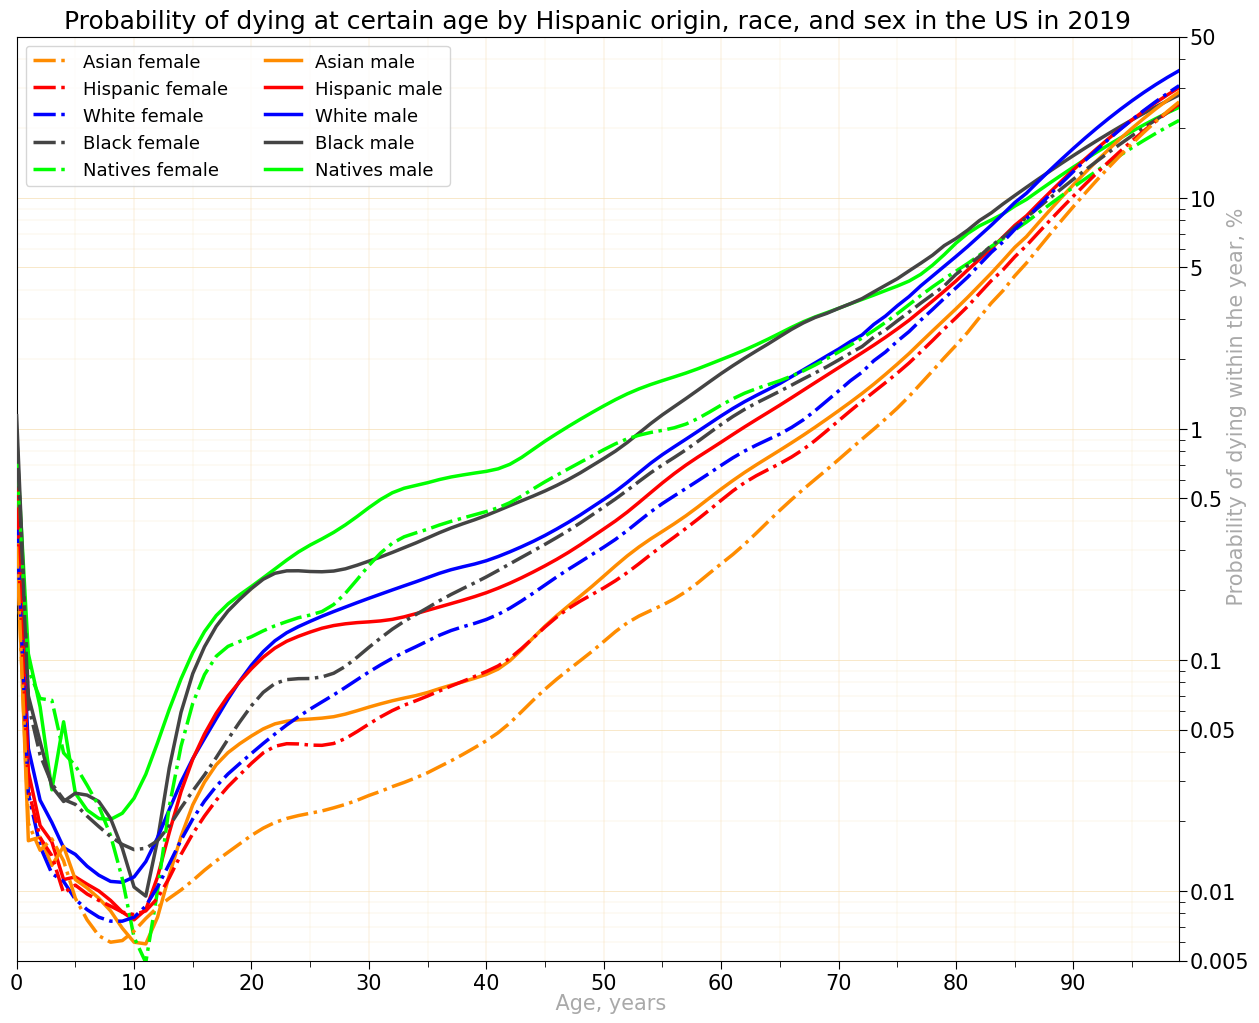

In [20]:
dd_display = {
    'asian_f'     : DisplayedGroup(en_name='Asian female',     ru_name='Азиаты -женщины',           color='darkorange', style='-.',  width=2.5, alpha=1),
    'asian_m'     : DisplayedGroup(en_name='Asian male',       ru_name='Азиаты -мужчины',           color='darkorange', style='-', width=2.5, alpha=1),
    'hispanic_f'  : DisplayedGroup(en_name='Hispanic female',  ru_name='Латиноамериканцы -женщины', color='red',        style='-.',  width=2.5, alpha=1),
    'hispanic_m'  : DisplayedGroup(en_name='Hispanic male',    ru_name='Латиноамериканцы -мужчины', color='red',        style='-', width=2.5, alpha=1),
    'white_f'     : DisplayedGroup(en_name='White female',     ru_name='Белые -женщины',            color='blue',       style='-.',  width=2.5, alpha=1),
    'white_m'     : DisplayedGroup(en_name='White male',       ru_name='Белые -мужчины',            color='blue',       style='-', width=2.5, alpha=1),
    'black_f'     : DisplayedGroup(en_name='Black female',     ru_name='Афроамериканцы -женщины',   color='#444444',    style='-.',  width=2.5, alpha=1),
    'black_m'     : DisplayedGroup(en_name='Black male',       ru_name='Афроамериканцы -мужчины',   color='#444444',    style='-', width=2.5, alpha=1),
    'native_f'    : DisplayedGroup(en_name='Natives female',   ru_name='Коренные жители -женщины',  color='lime',       style='-.',  width=2.5, alpha=1),
    'native_m'    : DisplayedGroup(en_name='Natives male',     ru_name='Коренные жители -мужчины',  color='lime',       style='-', width=2.5, alpha=1),
}

for lang in LANGS:
    create_chart(df.T.loc[['asian_f', 'hispanic_f', 'white_f', 'black_f', 'native_f', 'asian_m', 'hispanic_m', 'white_m', 'black_m', 'native_m']],
             dd_display=dd_display, ncol=2, lang=lang,
             plateau_years=plateau_years, show_plateau=False,
             age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
             title_en='Probability of dying at certain age by Hispanic origin, race, and sex in the US in 2019',
             title_ru='Вероятность смерти в определённом возрасте в зависимости от происхождения, расы и пола в США в 2019',
             file_name='Probability of Dying at Certain Age in the US')

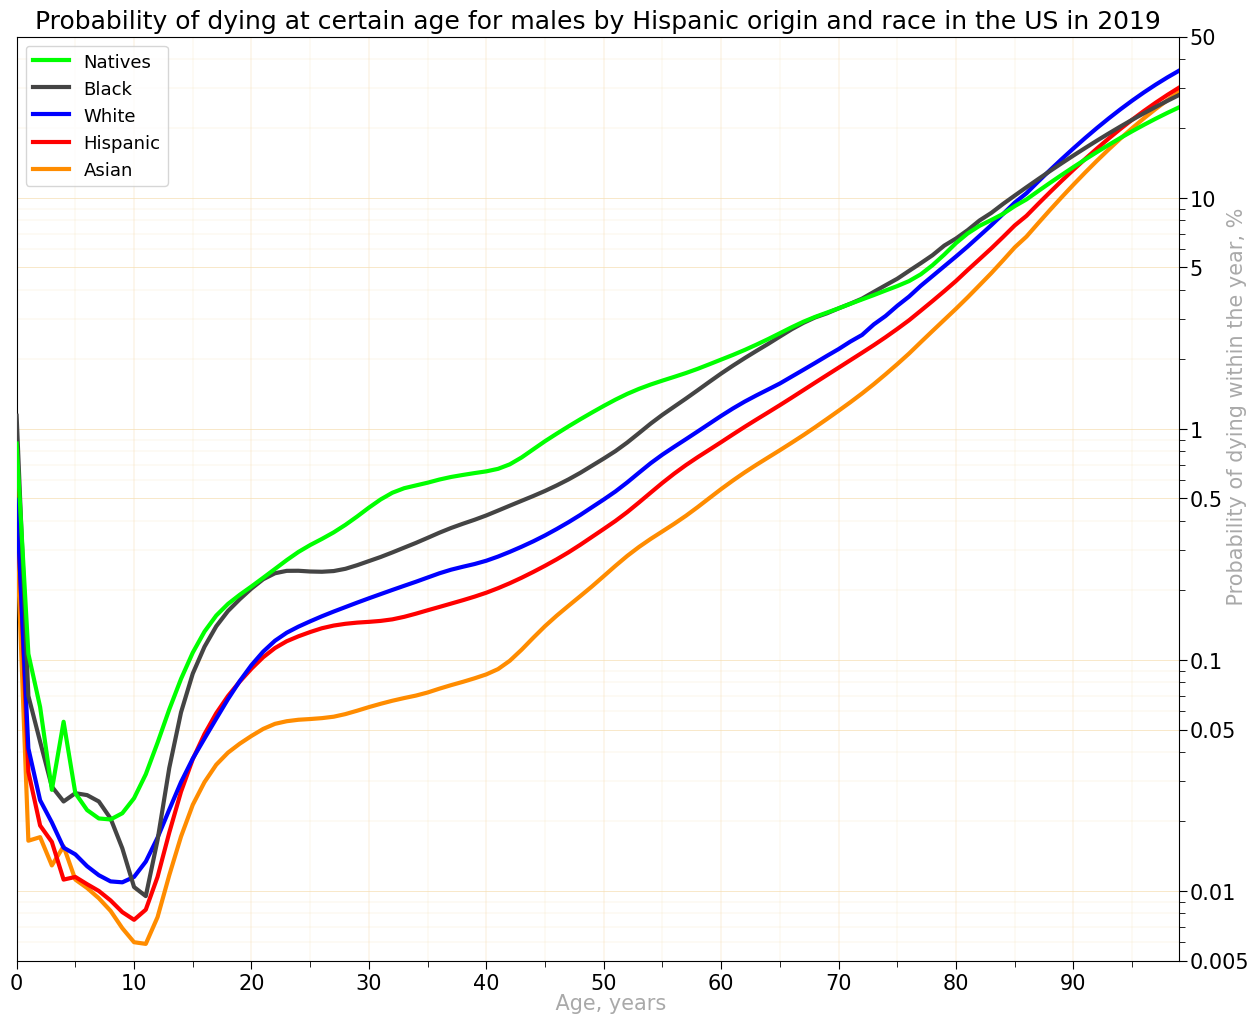

In [21]:
dd_display = {
    'asian_m'     : DisplayedGroup(en_name='Asian',       ru_name='Азиаты',           color='darkorange', style='-', width=3, alpha=1),
    'hispanic_m'  : DisplayedGroup(en_name='Hispanic',    ru_name='Латиноамериканцы', color='red',        style='-', width=3, alpha=1),
    'white_m'     : DisplayedGroup(en_name='White',       ru_name='Белые',            color='blue',       style='-', width=3, alpha=1),
    'black_m'     : DisplayedGroup(en_name='Black',       ru_name='Афроамериканцы',   color='#444444',    style='-', width=3, alpha=1),
    'native_m'    : DisplayedGroup(en_name='Natives',     ru_name='Коренные жители',  color='lime',       style='-', width=3, alpha=1),
}

for lang in LANGS:
    create_chart(df.T.loc[['native_m', 'black_m', 'white_m', 'hispanic_m', 'asian_m']],
             dd_display=dd_display, ncol=1, lang=lang,
             plateau_years=plateau_years, show_plateau=False,
             age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
             title_en='Probability of dying at certain age for males by Hispanic origin and race in the US in 2019',
             title_ru='Вероятность смерти в определённом возрасте мужчин в зависимости от происхождения и расы в США в 2019',
             file_name='Probability of Dying at Certain Age in the US -males')

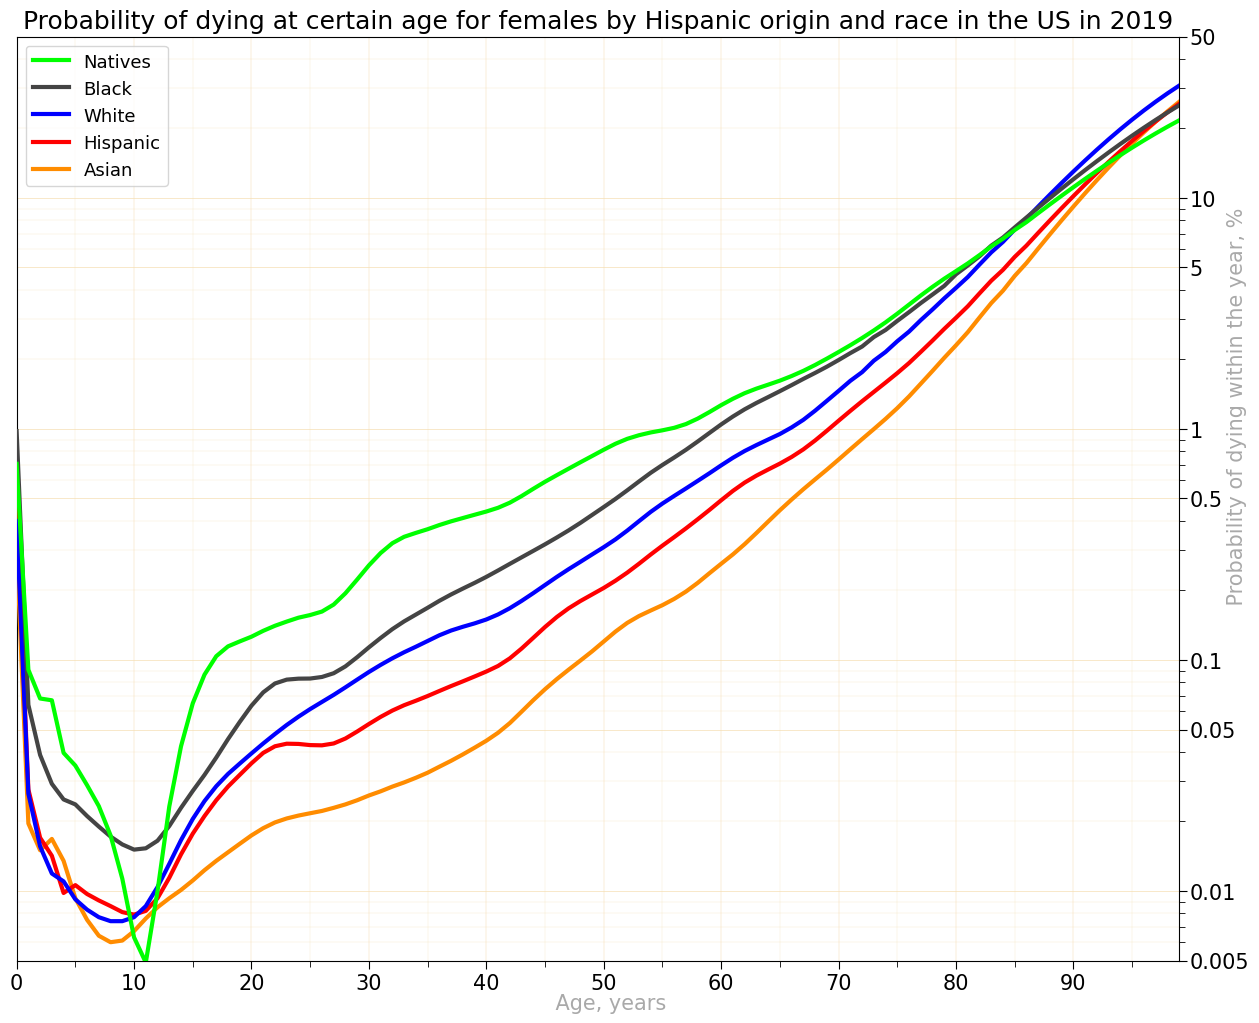

In [22]:
dd_display = {
    'asian_f'     : DisplayedGroup(en_name='Asian',     ru_name='Азиатки',           color='darkorange', style='-',  width=3, alpha=1),
    'hispanic_f'  : DisplayedGroup(en_name='Hispanic',  ru_name='Латиноамериканки', color='red',        style='-',  width=3, alpha=1),
    'white_f'     : DisplayedGroup(en_name='White',     ru_name='Белые',            color='blue',       style='-',  width=3, alpha=1),
    'black_f'     : DisplayedGroup(en_name='Black',     ru_name='Афроамериканки',   color='#444444',    style='-',  width=3, alpha=1),
    'native_f'    : DisplayedGroup(en_name='Natives',   ru_name='Коренные жительницы',  color='lime',       style='-',  width=3, alpha=1)
}

for lang in LANGS:
    create_chart(df.T.loc[['native_f', 'black_f', 'white_f', 'hispanic_f', 'asian_f']],
             dd_display=dd_display, ncol=1, lang=lang,
             plateau_years=plateau_years, show_plateau=False,
             age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
             title_en='Probability of dying at certain age for females by Hispanic origin and race in the US in 2019',
             title_ru='Вероятность смерти в определённом возрасте женщин в зависимости от происхождения и расы в США в 2019',
             file_name='Probability of Dying at Certain Age in the US -females')

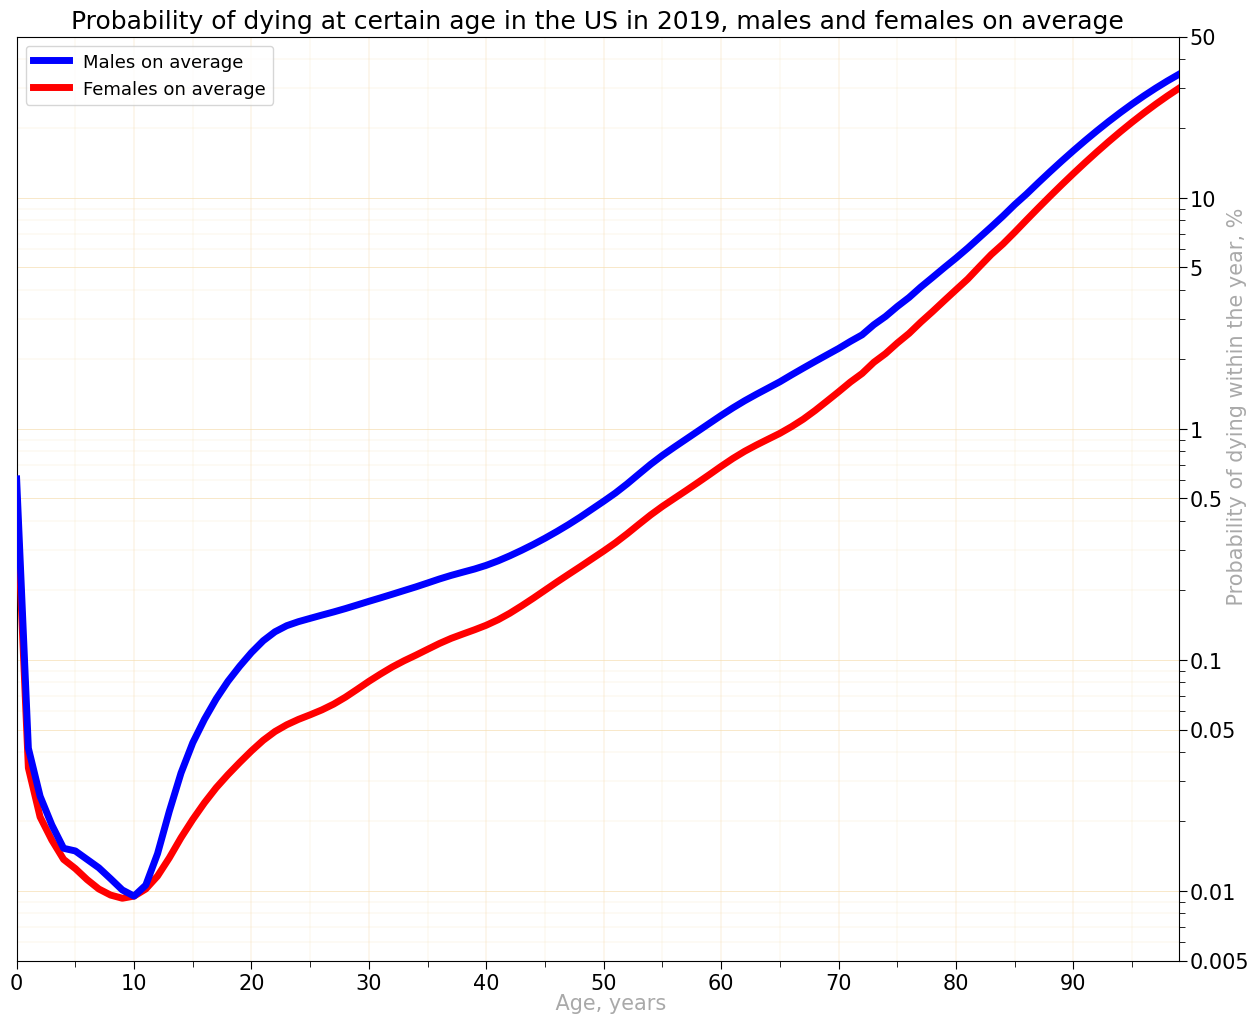

In [23]:
dd_display = {
    'all_f'       : DisplayedGroup(en_name='Females on average', ru_name='Женщины в среднем', color='red',  style='-', width=5, alpha=1),
    # 'all_t'       : DisplayedGroup(en_name='Population Overall', ru_name='население в целом', color='lightgrey', style='-', width=6, alpha=1),
    'all_m'       : DisplayedGroup(en_name='Males on average',   ru_name='Мужчины в среднем', color='blue', style='-', width=5, alpha=1),
}

for lang in LANGS:
    create_chart(df.T.loc[['all_m', 'all_f']],
             dd_display=dd_display, ncol=1, lang=lang,
             plateau_years=plateau_years, show_plateau=False,
             age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
             title_en='Probability of dying at certain age in the US in 2019, males and females on average',
             title_ru='Вероятность смерти в определённом возрасте в США в 2019, мужчины и женщины в среднем',
             file_name='Probability of Dying at Certain Age in the US -average')

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau for all_m     :  0.153 %,   Life expectancy:  650
Average mortality rate at the plateau for all_f     :  0.061 %,   Life expectancy: 1640

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Annual increase for all_m     :  8.48 %,   doubling period:  8.52 years
Annual increase for all_f     :  9.21 %,   doubling period:  7.87 years


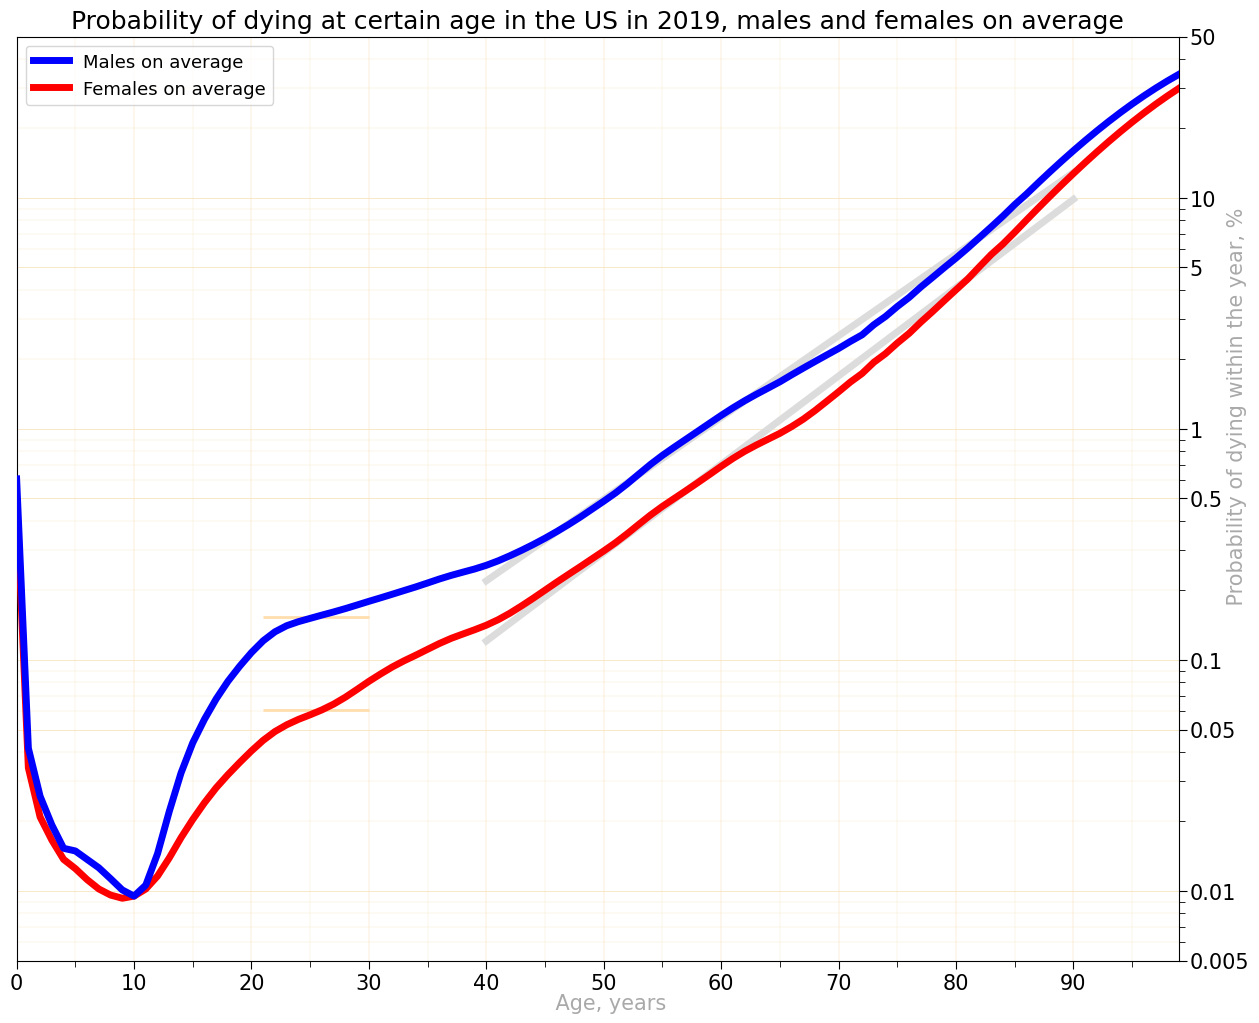

In [44]:
for lang in LANGS:
    create_chart(df.T.loc[['all_m', 'all_f']],
             dd_display=dd_display, ncol=1, lang=lang,
             plateau_years=plateau_years, show_plateau=True,
             age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
             title_en='Probability of dying at certain age in the US in 2019, males and females on average',
             title_ru='Вероятность смерти в определённом возрасте в США в 2019, мужчины и женщины в среднем',
             file_name='Probability of Dying at Certain Age in the US -gompertz')